In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import keyring
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# User set the main directory using keyring.  For example:
#    import keyring
#    keyring.set_password('msp', 'vmt_reduction_dir', 'path to the desired directory')
# This will be saved on your local machine

teams_dir = keyring.get_password('msp', 'vmt_reduction_dir')

In [3]:
df = pd.read_csv(teams_dir + "/data_processed/tbi_cleaned.csv")
df

C:\Users\fishl\AppData\Local\Temp\ipykernel_2068\3044256175.py:1: DtypeWarning: Columns (33,34,35,52,64,65,66,67,68,69,70) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(teams_dir + "/data_processed/tbi_cleaned.csv")


,Unnamed: 0,wave,hh_id,person_id,person_num,day_num,linked_trip_id,trip_id,travel_date,travel_dow,...,transportation_barriers_4,transportation_barriers_5,transportation_barriers_997,transportation_barriers_999,day_complete,trip_survey_complete,hh_weight,person_weight,day_weight,trip_weight
0,0,1,18112062,1811206201,1,1,1.0,[1811206201001],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
1,1,1,18112062,1811206201,1,1,2.0,[1811206201002],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
2,2,1,18112062,1811206203,3,1,1.0,[1811206203001],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
3,3,1,18112062,1811206203,3,1,2.0,[1811206203002],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
4,4,1,18112062,1811206204,4,1,1.0,[1811206204001],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
454176,512248,2,22002790,2200279003,3,1,212556.0,[2200279003003],2022-01-27,Thursday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,20.910320,20.910320,20.910320,32.363497
454177,512249,2,22002791,2200279101,1,1,212557.0,[2200279101001],2022-01-26,Wednesday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,53.032499,53.032499,53.032499,53.032499
454178,512250,2,22002791,2200279101,1,1,212558.0,[2200279101002],2022-01-26,Wednesday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,53.032499,53.032499,53.032499,53.032499
454179,512251,2,22002791,2200279102,2,1,212559.0,[2200279102001],2022-01-26,Wednesday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,53.032499,53.032499,53.032499,53.032499


In [4]:
MILES_PER_METER = 0.000621371

## Car Analysis

In [18]:
car = pd.read_parquet(teams_dir + "/Data_processed/geodata/car_congestion_nogeom.parquet")
car

duration_seconds  distance_meters  weight
level_0       trip_id                                                   
saturdays_0-6 [1811206201001]            1200.1          25865.4  1200.1
              [1811206201002]            1202.7          25893.0  1202.7
              [1811206203001]             929.0          14919.2   929.0
              [1811206203002]             952.6          14901.2   952.6
              [1811206204001]             769.8          13357.8   769.8
...                                         ...              ...     ...
weekdays_9-10 [2200279003003]             445.7           4274.8   452.4
              [2200279101001]             618.6           5952.1   618.6
              [2200279101002]             620.9           5951.6   620.9
              [2200279102001]             395.3           4843.6   395.3
              [2200279102002]             393.8           4428.9   393.8

[22014576 rows x 3 columns]

In [19]:
def get_car_data(row, field):
    hour = int(row["arrive_time"][0:2])
    sunday = row["travel_dow"] == "Sunday"
    saturday = row["travel_dow"] == "Saturday"
    if sunday:
        query = "sundays"
    elif saturday:
        query = "saturdays_"
    else:
        query = "weekdays_"
    
    if hour >= 0 and hour <= 5:
        query += "0-6"
    elif hour >= 20 and hour <= 23:
        query += "20-24"
    else:
        query += str(hour) + "-" + str(hour + 1)

    if (query, row["trip_id"]) not in car.index:
        print(row["trip_id"])
        return np.nan

    return car.loc[(query, row["trip_id"])][field]

In [20]:
df["rerouting_duration_car"] = df.apply(lambda x: get_car_data(x, "duration_seconds"), axis=1) / 60
df["rerouting_distance_car"] = df.apply(lambda x: get_car_data(x, "distance_meters"), axis=1) * MILES_PER_METER

[1926680701020]
[1926680701020]


Comparing the summary statistics, it seems that rerouting durations genreally seem to underestmate trip durations in nearly all indicators

In [21]:
pd.concat([df[df["mode"] == "Car"]["rerouting_duration_car"].describe(), df[df["mode"] == "Car"]["duration"].describe()], axis=1)

,rerouting_duration_car,duration
count,380026.000000,380027.000000
mean,12.609590,18.652677
std,10.633773,21.940639
min,0.000000,0.100000
25%,5.373333,8.100000
50%,9.593333,13.800000
75%,16.588333,22.100000
max,139.815000,971.000000


Rerouting analysis seems to generally underestmiate trip durations, with most linked trips being below the y=x line in the scatter plot below. This could be due to implicit bias in the sampled durations in the TBI data, with self-reported/estimated durations not being representative of the actual trip. This could also be due to the cleaning that was done to clean duration values (and the lack of cleaning in some cases, as seen with the rightmost outliers).

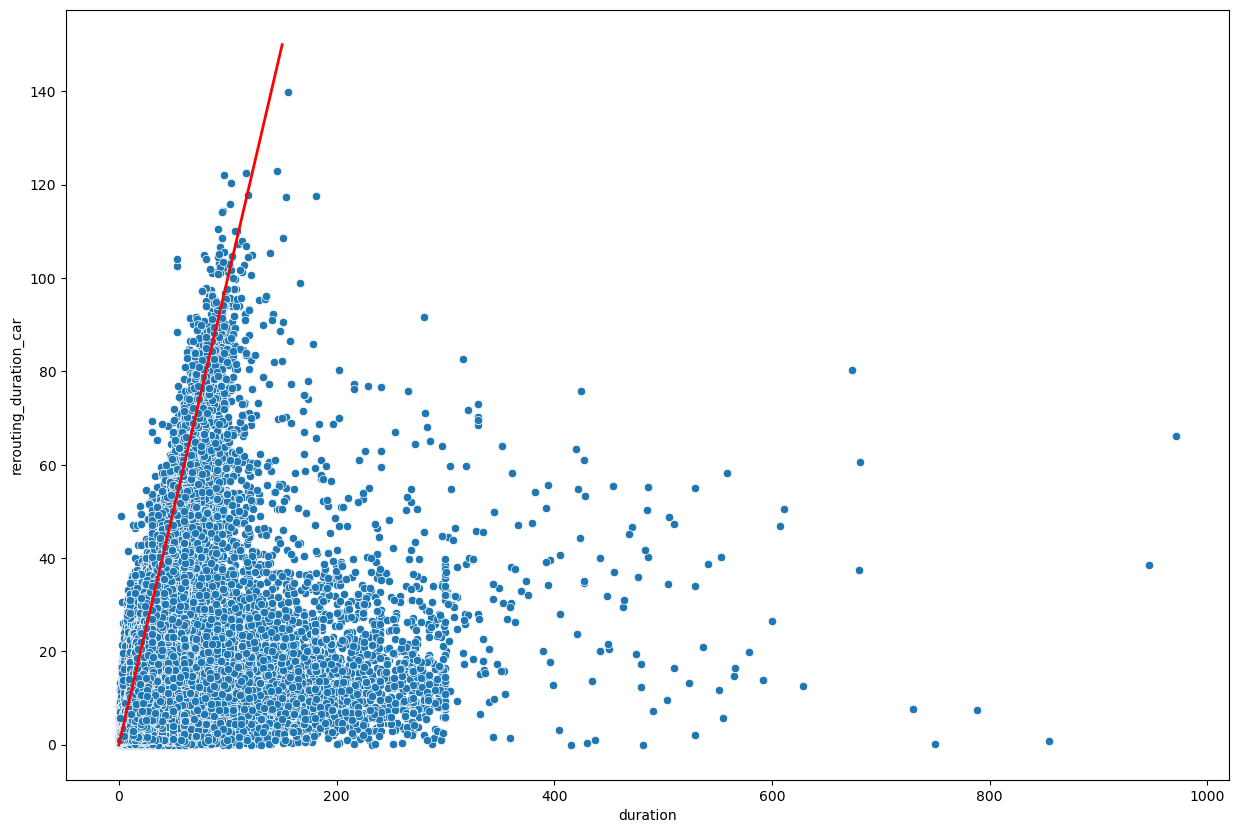

In [22]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.scatterplot(data=df[df["mode"] == "Car"], x="duration", y="rerouting_duration_car", ax=ax)
x_ref = np.linspace(0, 150)
plt.plot(x_ref, x_ref, color="r", linewidth=2)

The summary statistics mirror the graph, with about 75% of all linked trips having greater actual durations than rerouting durations. It should be noted that for 90% of trips, the absolute difference is less than 10 minutes, which is relatively negligible.

In [23]:
(df[df["mode"] == "Car"]["duration"] - df[df["mode"] == "Car"]["rerouting_duration_car"]).describe(percentiles=[0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 0.75, 0.8, 0.85, 0.9, 0.95])

count    380026.000000
mean          6.043120
std          18.995604
min         -51.148333
5%           -2.973333
10%          -1.653333
15%          -0.921667
20%          -0.356667
25%           0.158333
50%           2.718333
75%           6.276667
80%           7.580000
85%           9.463333
90%          12.726667
95%          21.038333
max         908.181667
dtype: float64

This scatter plot outlines the difference between duration of non-car modes and their corresponding rerouted car durations. As is to be expected, for the vast majority of trips, going by car beats going by the non-car mode (most of the points are below the y=x line).

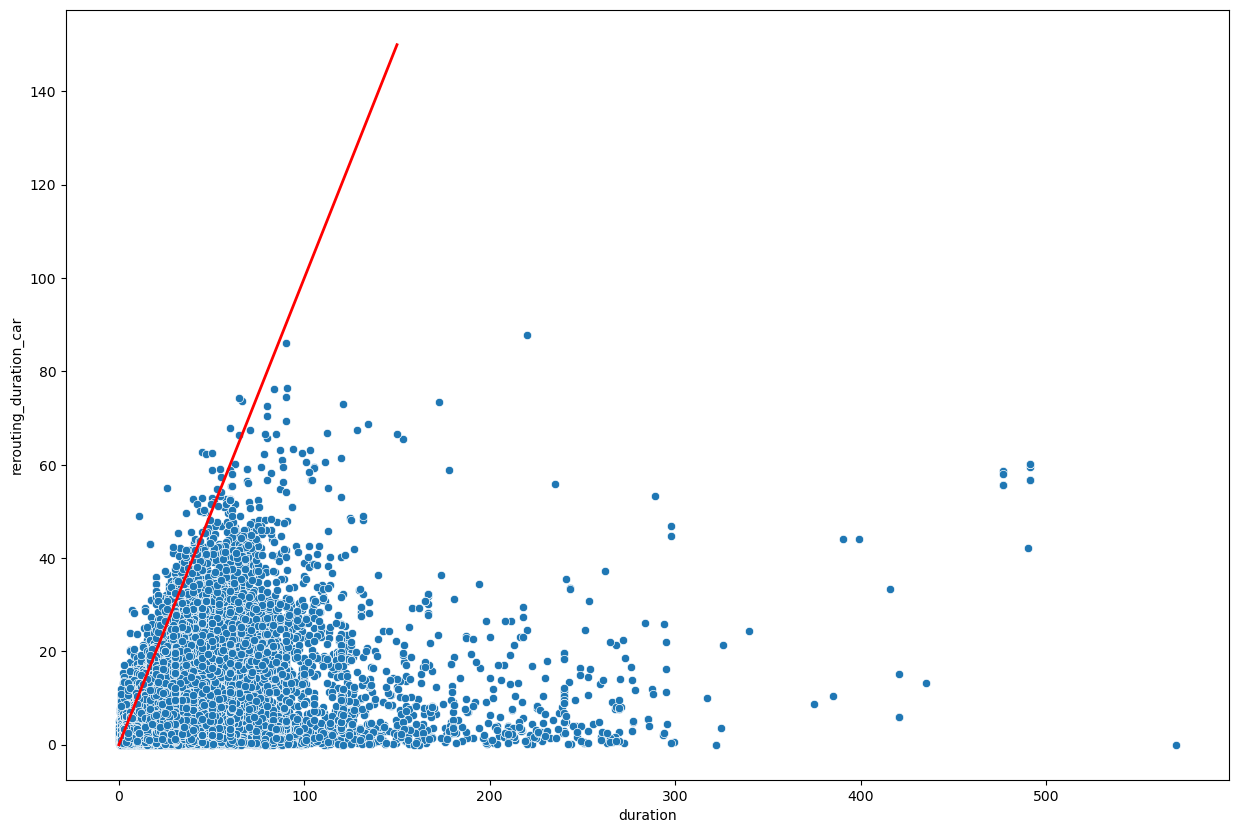

In [24]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.scatterplot(data=df[df["mode"] != "Car"], x="duration", y="rerouting_duration_car", ax=ax)
x_ref = np.linspace(0, 150)
plt.plot(x_ref, x_ref, color="r", linewidth=2)

This is once again mirrored by the summary statistics, with only about 5% of all linked non-car trips having parity/being faster than their corresponding rerouted car duration.

In [25]:
(df[df["mode"] != "Car"]["duration"] - df[df["mode"] != "Car"]["rerouting_duration_car"]).describe(percentiles=[0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 0.75, 0.8, 0.85, 0.9, 0.95])

count    74154.000000
mean        15.179233
std         21.904264
min        -37.965000
5%           0.358333
10%          1.795000
15%          2.853333
20%          3.858333
25%          4.793333
50%          9.842500
75%         18.318428
80%         21.360000
85%         25.258333
90%         31.262333
95%         44.189250
max        570.000000
dtype: float64

Unlike with duration, rerouting distances of car trips seem to be generally longer than the corresponding reported TBI distance. This may be one reason the durations are greater in the rerouting analysis.

In [26]:
pd.concat([df[df["mode"] == "Car"]["rerouting_distance_car"].describe(), df[df["mode"] == "Car"]["distance"].describe()], axis=1)

,rerouting_distance_car,distance
count,380026.000000,380027.000000
mean,7.282469,7.029822
std,8.608094,8.605750
min,0.000000,0.010271
25%,1.761214,1.650660
50%,4.201524,3.931170
75%,9.657395,9.216220
max,119.531834,99.978130


This scatter plot shows the difference in distances between observed and rerouted distances for observed car linked trips. In general, it seems that the rerouting distances seem to roughly match the actual distances for observed car trips, although it is slightly bottom heavy (actual distances are lower).

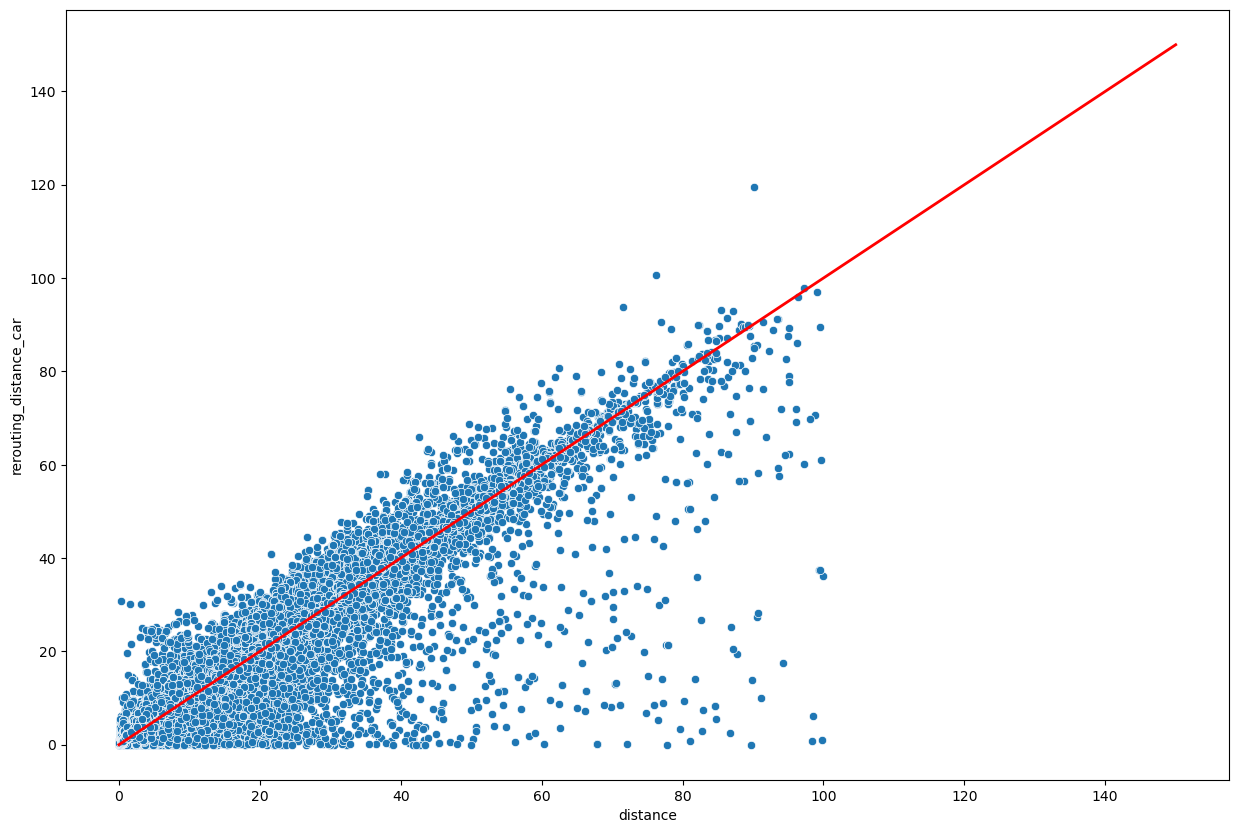

In [27]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.scatterplot(data=df[df["mode"] == "Car"], x="distance", y="rerouting_distance_car", ax=ax)
x_ref = np.linspace(0, 150)
plt.plot(x_ref, x_ref, color="r", linewidth=2)

The summary statsitics reflect the graph. Roughly 75% of all trips have a greater rerouting distance, with the other 25% having a greater observed distance. 

In [28]:
(df[df["mode"] == "Car"]["distance"] - df[df["mode"] == "Car"]["rerouting_distance_car"]).describe(percentiles=[0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95])

count    380026.000000
mean         -0.252628
std           2.134959
min         -30.374107
5%           -2.555314
10%          -1.522414
15%          -1.023424
20%          -0.728003
25%          -0.540395
50%          -0.147171
60%          -0.076445
70%          -0.016494
75%           0.021531
80%           0.100602
85%           0.247175
90%           0.554755
95%           1.397223
max          98.670302
dtype: float64

This scatter plot shows the observed and car-rerouted distances for non-car linked trips. This roughly reflects what was seen in the car linked trip graph above, which is reasonable as distance likely doesn't change drastically between a car and its corresponding non-car trip.

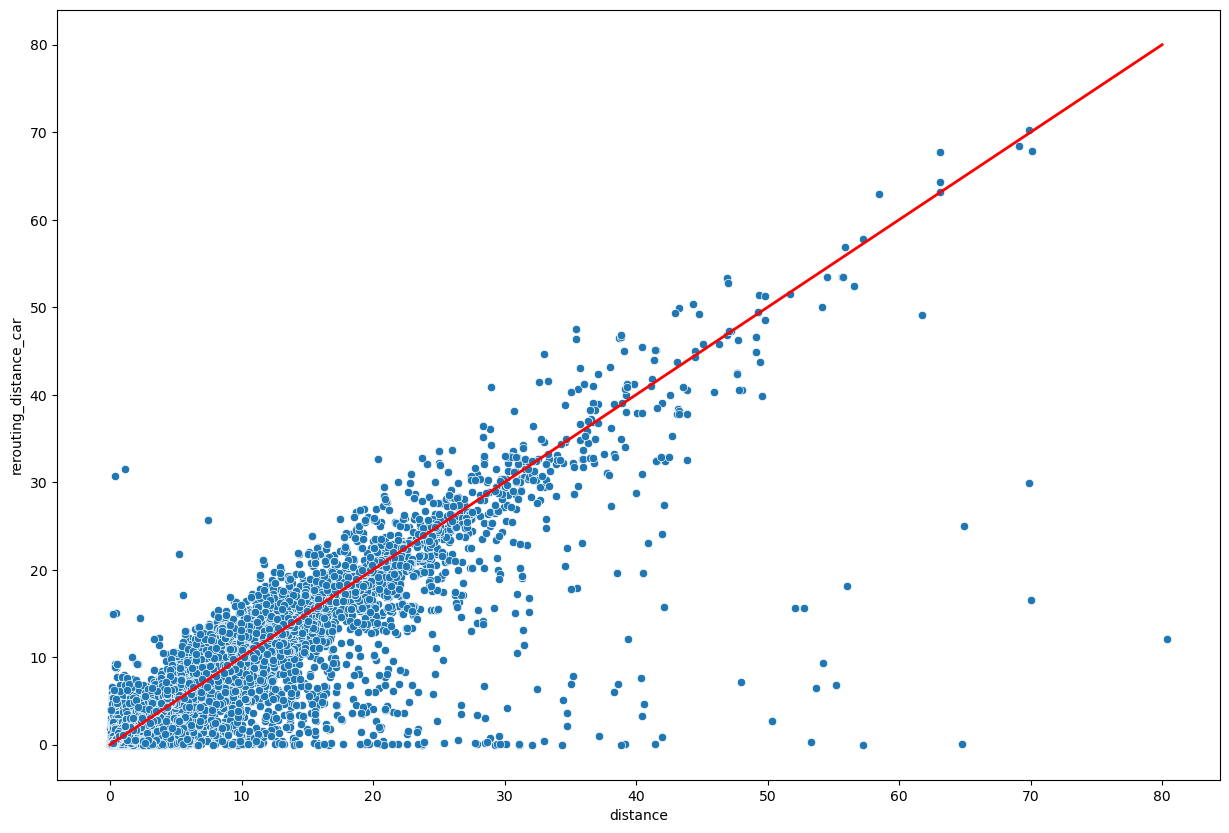

In [29]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.scatterplot(data=df[df["mode"] != "Car"], x="distance", y="rerouting_distance_car", ax=ax)
x_ref = np.linspace(0, 80)
plt.plot(x_ref, x_ref, color="r", linewidth=2)

The summary statistics also roughly reflect what was seen with the car linked trips.

In [30]:
(df[df["mode"] != "Car"]["distance"] - df[df["mode"] != "Car"]["rerouting_distance_car"]).describe(percentiles=[0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95])

count    74154.000000
mean        -0.026909
std          1.690374
min        -30.339927
5%          -1.457034
10%         -0.791283
15%         -0.495644
20%         -0.347455
25%         -0.256015
50%         -0.052579
60%         -0.018229
70%          0.008895
75%          0.038865
80%          0.097135
85%          0.206378
90%          0.451411
95%          1.176642
max         68.287356
dtype: float64

## Bike/Scooter Analysis

In [31]:
bike_lts = pd.read_parquet(teams_dir + "/Data_processed/geodata/bike_lts.parquet")
bike_lts

,trip_id,duration_seconds,distance_meters,weight,distance_meters_1,distance_meters_2,distance_meters_3,distance_meters_4,geometry
0,[1811206201001],21781.8,35771.3,14002.7,31340.529135,298.150005,3734.391881,397.351353,b'\x01\x02\x00\x00\x00\xb4\x01\x00\x00\xef\xae...
1,[1811206201002],21781.8,35771.3,14002.7,31340.529135,298.150005,3734.391881,397.351353,b'\x01\x02\x00\x00\x00\xb4\x01\x00\x00\xc8#\xb...
2,[1811206203001],15218.0,25992.0,10165.6,24928.078483,298.150005,129.130877,636.653314,b'\x01\x02\x00\x00\x00\x1e\x02\x00\x00\xef\xae...
3,[1811206203002],15241.3,25997.8,10172.9,24933.897999,298.150005,129.130877,636.653314,b'\x01\x02\x00\x00\x00 \x02\x00\x00J\x9a?\xa6\...
4,[1811206204001],13104.0,23178.3,8545.7,22358.880570,298.150005,85.485012,435.807499,b'\x01\x02\x00\x00\x00\xfd\x01\x00\x00\xef\xae...
...,...,...,...,...,...,...,...,...,...
458633,[2200279003003],6138.5,13541.8,2782.3,11780.143850,1689.470227,44.290975,27.871214,b'\x01\x02\x00\x00\x00\xde\x01\x00\x004\xd8\xd...
458634,[2200279101001],8034.1,14334.2,4315.9,13878.443165,0.000000,225.336566,230.453257,b'\x01\x02\x00\x00\x00\xed\x01\x00\x00@\xdd@\x...
458635,[2200279101002],8034.1,14334.2,4315.9,13878.443165,0.000000,225.336566,230.453257,b'\x01\x02\x00\x00\x00\xed\x01\x00\x00Zf\x11\x...
458636,[2200279102001],4119.1,7267.8,2545.0,6976.301425,68.723028,7.893996,214.921328,b'\x01\x02\x00\x00\x00\xf9\x00\x00\x00@\xdd@\x...


In [106]:
df["rerouting_duration_bike"] = (bike_lts.set_index("trip_id").loc[df["trip_id"]]["weight"] / 60).values # use weight instead of duration
df["rerouting_duration_bike_old"] = (bike_lts.set_index("trip_id").loc[df["trip_id"]]["duration_seconds"] / 60).values # use weight instead of duration
df["rerouting_distance_bike"] = (bike_lts.set_index("trip_id").loc[df["trip_id"]]["distance_meters"] * MILES_PER_METER).values

Going from the comparative summary statistics, it seems that rerouted durations for observed bike trips tend to be somewhat greater than the corresponding reported durations in the TBI data.

In [35]:
pd.concat([df[df["mode"] == "Bike/Scooter"]["rerouting_duration_bike"].describe(), df[df["mode"] == "Bike/Scooter"]["duration"].describe()], axis=1)

,rerouting_duration_bike,duration
count,7692.000000,7692.000000
mean,31.883323,23.616316
std,30.071452,25.960970
min,0.000000,0.600000
25%,13.680833,9.000000
50%,24.905000,16.000000
75%,41.244583,29.000000
max,640.430000,325.800000


This scatter plot shows the observed versus rerouted durations for observed bike trips. In general, most linked trips are above the y=x line, meaning that most linked trips have rerouted durations that are greater than their corresponding reported duration in the TBI data. There are also some trips that have absurd rerouted durations, which could be due to error with duration handling in the TBI cleaning process.

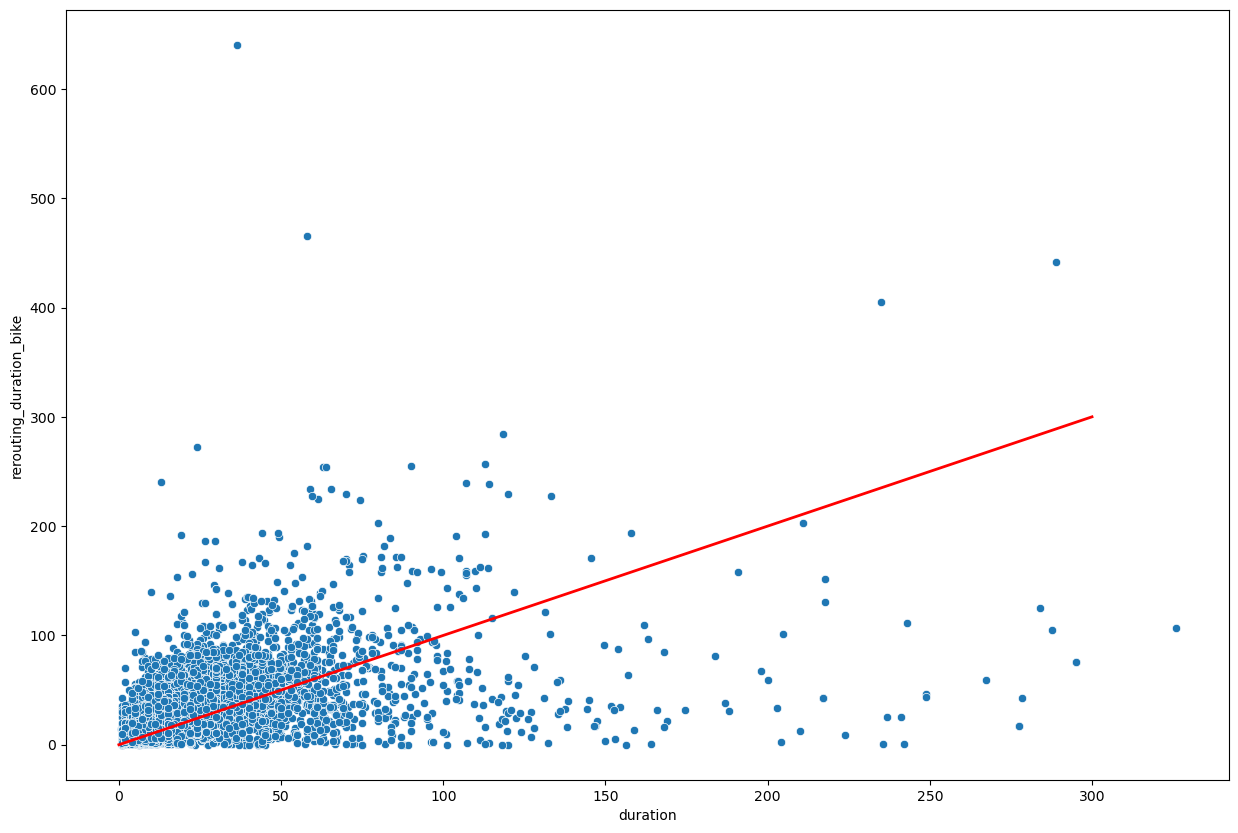

In [36]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.scatterplot(data=df[df["mode"] == "Bike/Scooter"], x="duration", y="rerouting_duration_bike", ax=ax)
x_ref = np.linspace(0, 300)
plt.plot(x_ref, x_ref, color="r", linewidth=2)

This reflects what was seen in the above chart. About 90% of all observed bike trips have rerouted durations that were greater than their corresponding observed duration, and the central magnitudes for these duration differences are not insignificant (35 minutes for mean; 26 minutes for median).

In [41]:
(df[df["mode"] == "Bike/Scooter"]["duration"] - df[df["mode"] == "Bike/Scooter"]["rerouting_duration_bike"]).describe(percentiles=[0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95])

count    7692.000000
mean       -8.267007
std        29.818281
min      -604.130000
5%        -46.750000
10%       -33.665500
15%       -26.916167
20%       -22.142667
25%       -18.625000
50%        -7.625833
60%        -4.000333
70%        -0.350000
75%         1.591667
80%         3.815000
85%         7.207917
90%        13.303333
95%        27.358917
max       260.735000
dtype: float64

An analsyis of rerouted bike durations for non-bike trips is left out, as non-bike trips would include car trips, which would muddle the conclusions that could be drawn.

We will thus begin with bike/scooter distance analysis. In general, from the side by side summary statistics, it seems that rerouted distances tend to be greater than observed distances.

In [42]:
pd.concat([df[df["mode"] == "Bike/Scooter"]["rerouting_distance_bike"].describe(), df[df["mode"] == "Bike/Scooter"]["distance"].describe()], axis=1)

,rerouting_distance_bike,distance
count,7692.000000,7692.000000
mean,3.744724,3.239614
std,4.297965,4.222073
min,0.000000,0.057926
25%,1.122584,0.834450
50%,2.378422,1.857828
75%,4.779244,4.057700
max,81.547114,80.358668


This scatter plot shows observed/reported distances versus rerouted distances for observed bike trips. In general, despite the variance in the summary statistics, it seems that the observed and rerouted distances tend to match up, clustering around the y=x line, with the bottom being marginally heavier (observed distances are larger than rerouted distances).

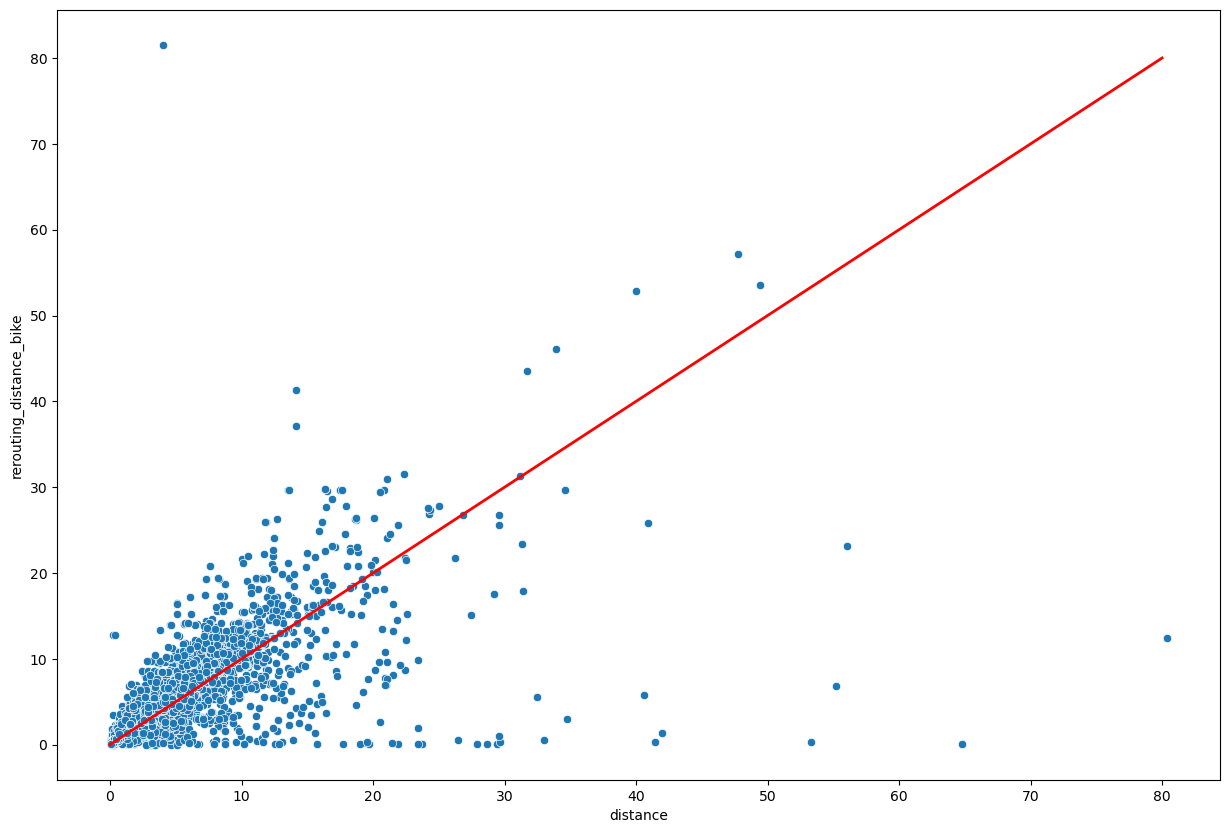

In [43]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.scatterplot(data=df[df["mode"] == "Bike/Scooter"], x="distance", y="rerouting_distance_bike", ax=ax)
x_ref = np.linspace(0, 80)
plt.plot(x_ref, x_ref, color="r", linewidth=2)

Analyzing the summary statistics of the difference between observed and rerouted distances for observed bike trips, it seems that, like with bike durations, the rerouted distances seem to be generally larger than their observed counterparts (this accounts for about 80% of all bike linked trips). However, the magnitudes of these differences are not as large as with durations, with the mean/median differences having magnitudes of 0.5 miles. 

In [44]:
(df[df["mode"] == "Bike/Scooter"]["distance"] - df[df["mode"] == "Bike/Scooter"]["rerouting_distance_bike"]).describe(percentiles=[0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95])

count    7692.000000
mean       -0.505111
std         3.087112
min       -77.486454
5%         -3.451940
10%        -2.345147
15%        -1.734247
20%        -1.385659
25%        -1.094777
50%        -0.400714
60%        -0.234732
70%        -0.108530
75%        -0.054416
80%        -0.008911
85%         0.080883
90%         0.424110
95%         1.811248
max        67.871472
dtype: float64

## Walking analysis

In [115]:
walk = pd.read_parquet(teams_dir + "/Data_processed/geodata/walk_trips_nogeom.parquet")
walk

,trip_id,duration_seconds,distance_meters,weight
0,[1811206201001],21312.0,26137.5,21312.0
1,[1811206201002],21312.0,26137.5,21312.0
2,[1811206203001],10848.5,15066.6,10848.5
3,[1811206203002],10848.5,15066.6,10848.5
4,[1811206204001],10290.3,14292.2,10290.3
...,...,...,...,...
458645,[2200279003003],2751.3,3821.7,2751.3
458646,[2200279101001],4248.0,5894.8,4248.0
458647,[2200279101002],4248.0,5894.8,4248.0
458648,[2200279102001],3210.6,4453.7,3210.6


In [116]:
df["rerouting_duration_walk"] = (walk.set_index('trip_id').loc[df["trip_id"]]["duration_seconds"] / 60).values
df["rerouting_distance_walk"] = (walk.set_index('trip_id').loc[df["trip_id"]]["distance_meters"] * MILES_PER_METER).values

From the side by side comparison, it seems that the rerouting analysis seems to underestimate the duration of walk trips for observed walk trips. 

In [117]:
pd.concat([df[df["mode"] == "Walk"]["rerouting_duration_walk"].describe(), df[df["mode"] == "Walk"]["duration"].describe()], axis=1)

,rerouting_duration_walk,duration
count,49670.000000,49670.000000
mean,11.819962,16.067523
std,19.398401,18.711005
min,0.000000,0.100000
25%,4.421667,6.200000
50%,7.608333,11.300000
75%,13.251667,19.200000
max,997.553333,325.000000


This scatter plot shows the observed and rerouted durations for observed walk trips. In the scatter plot, there is a very large horizontal cluster for short rerouted duration along the entire duration axis, representing linked trips that had a greater duration than rerouted duration (indicating that rerouting underestimates duration). 

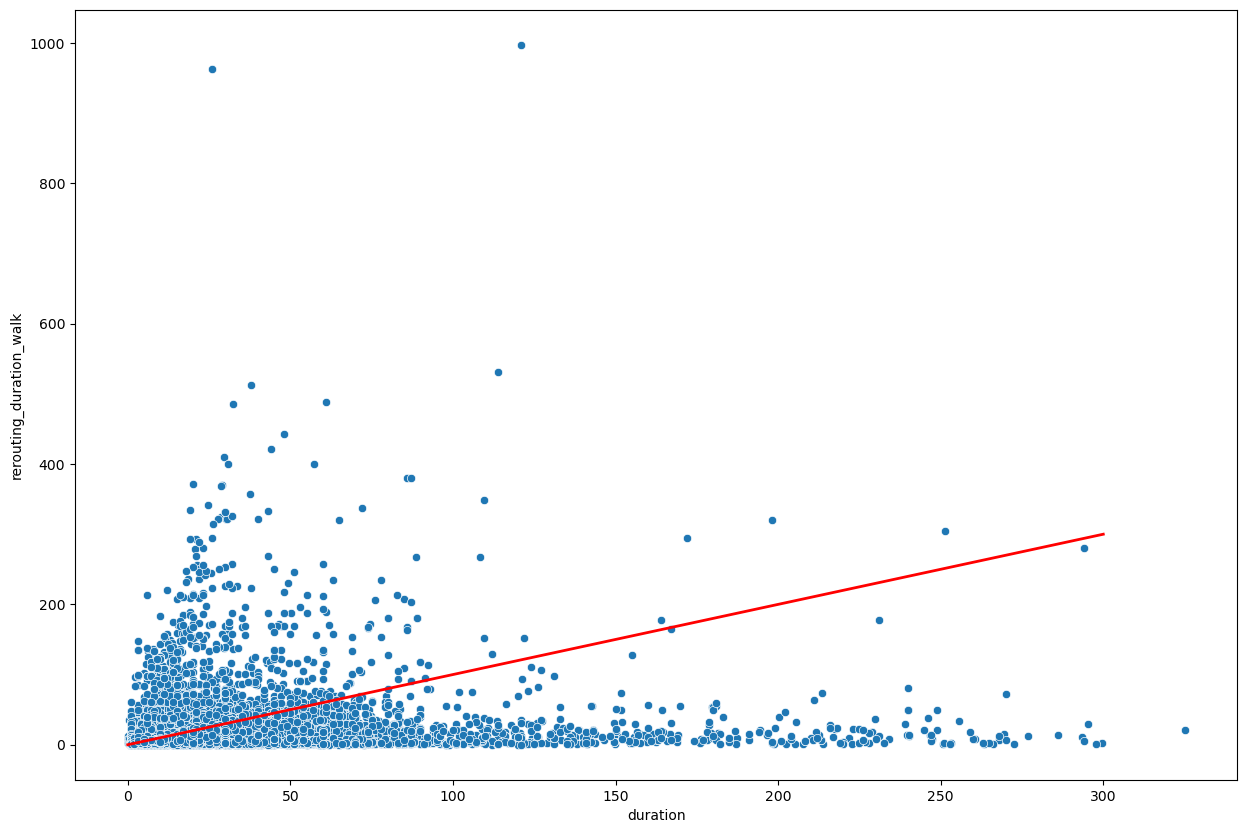

In [118]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.scatterplot(data=df[df["mode"] == "Walk"], x="duration", y="rerouting_duration_walk", ax=ax)
x_ref = np.linspace(0, 300)
plt.plot(x_ref, x_ref, color="r", linewidth=2)

It could be the case that this seemingly large difference between rerouted nad observed walking durations is due to the TBI data (the duration reported for walking trips are biased)--e.g., as seen below, trips taking longer than 100 minutes to complete have a median distance of 1.3 miles, which doesn't really make sense.

In [119]:
df[(df["mode"] == "Walk") & (df["duration"] > 100)]["distance"].describe()

count    376.000000
mean       3.020531
std        5.092276
min        0.175860
25%        0.768626
50%        1.363931
75%        3.150203
max       55.865006
Name: distance, dtype: float64

In [120]:
# temp = pd.read_csv(teams_dir + "/data_processed/tbi_merged.csv")

# temp["rerouting_duration_walk"] = (walk.set_index('trip_id').loc[temp["trip_id"]]["duration_seconds"] / 60).values
# temp["rerouting_distance_walk"] = (walk.set_index('trip_id').loc[temp["trip_id"]]["distance_meters"] * MILES_PER_METER).values

# fig, ax = plt.subplots(figsize=(15, 10))
# sns.scatterplot(data=temp[temp["mode"] == "Walk"], x="duration", y="rerouting_duration_walk", ax=ax)
# x_ref = np.linspace(0, 300)
# plt.plot(x_ref, x_ref, color="r", linewidth=2)
# ax.set_xlim(0, 300)

Despite the strange pattern seen in the above scatter plot, it seems that the vast majority of the rerouted walk durations match roughly with the observed durations--80% of all walking trips have a absolute difference of about 10 minutes between the two. Therefore, despite the strange outlier cluster observed, it seems that rerouting duration for walking trips are roughly accurate.

In [121]:
(df[df["mode"] == "Walk"]["duration"] - df[df["mode"] == "Walk"]["rerouting_duration_walk"]).describe(percentiles=[0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95])

count    49670.000000
mean         4.247561
std         23.215947
min       -936.950000
5%          -9.298333
10%         -3.825000
15%         -1.790000
20%         -0.772000
25%         -0.076250
50%          2.598333
60%          3.906667
70%          5.625500
75%          6.797917
80%          8.398667
85%         10.733333
90%         14.750333
95%         25.545333
max        304.263333
dtype: float64

The rerouting analysis for distance of observed walking trips seem to be more or less in-line with the observed disatnce of these trips.

In [122]:
pd.concat([df[df["mode"] == "Walk"]["rerouting_distance_walk"].describe(), df[df["mode"] == "Walk"]["distance"].describe()], axis=1)

,rerouting_distance_walk,distance
count,49670.000000,49670.000000
mean,0.610839,0.703522
std,1.001299,1.243842
min,0.000000,0.010238
25%,0.228665,0.217010
50%,0.393390,0.400441
75%,0.685124,0.764565
max,51.582244,55.865006


This scatter plot shows the observed TBI/rerouted disatnces for observed walking trips. Unlike with durations, the two seem to eb roughly in line, although with the bottom of hte line being slightly heavier (rerouting underestimates distance of trips more times than not).

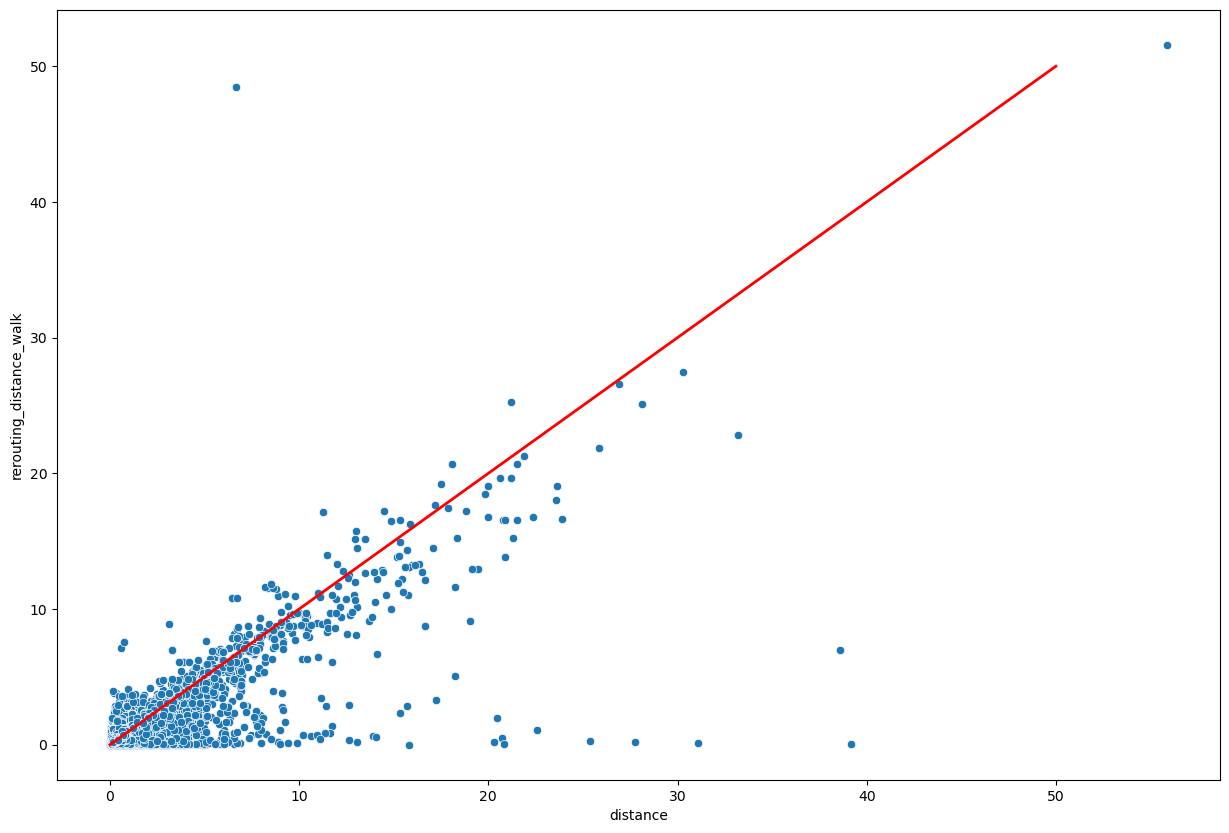

In [123]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.scatterplot(data=df[df["mode"] == "Walk"], x="distance", y="rerouting_distance_walk", ax=ax)
x_ref = np.linspace(0, 50)
plt.plot(x_ref, x_ref, color="r", linewidth=2)

The summary statistics of hte difference between observed/rerouted walking distance for observed walking trips mirros what was seen in the scatter plot and is relatively similar to the summary statistics for the duration difference for observed walking trips. Overall, the absolute idfference between the two is relatively low, with 85% of trips having an absolute difference of about 0.35 miles or less.

In [124]:
(df[df["mode"] == "Walk"]["distance"] - df[df["mode"] == "Walk"]["rerouting_distance_walk"]).describe(percentiles=[0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95])

count    49670.000000
mean         0.092683
std          0.712632
min        -41.822105
5%          -0.262281
10%         -0.149419
15%         -0.101831
20%         -0.074452
25%         -0.056731
50%         -0.008720
60%          0.006132
70%          0.038566
75%          0.070133
80%          0.117736
85%          0.199584
90%          0.355424
95%          0.735887
max         39.130382
dtype: float64

## Transit analysis

This analysis is only for the trips that have a corresponding found transit trip in the rerouting analysis.

In [55]:
transit = gpd.read_parquet(teams_dir + "/data_processed/geodata/transit_trips.parquet")

In [56]:
# calculate duration from star/tend times
transit["start_time_dt"] = pd.to_datetime(transit["start_time"])
transit["end_time_dt"] = pd.to_datetime(transit["end_time"])

transit["duration"] = (transit["end_time_dt"] - transit["start_time_dt"]).apply(lambda x: x.seconds / 60)

In [57]:
transit["num_transfers"] = (transit["leg_type"] == "TransitRouter.transfer") # temporary field to calculate number of transfers
transit["non_transit_duration"] = (transit["leg_type"].isin(["TransitRouter.access", "TransitRouter.egress"])) * (transit["duration"]) # non-transit time (access and egress)

In [58]:
# project to US equidistant projection to calculate lengths of paths (in meters)
# https://spatialreference.org/ref/esri/usa-contiguous-equidistant-conic/
transit = transit.to_crs("ESRI:102005")

In [59]:
transit["length"] = transit.length
transit["access_length"] = transit["length"]
transit

,trip_id,leg_index,start_time,end_time,origin_stop_id,origin_stop_name,destination_stop_id,destination_stop_name,route_id,route_short_name,...,route_type,leg_type,geometry,start_time_dt,end_time_dt,duration,num_transfers,non_transit_duration,length,access_length
0,[1811424401001],1,2023-01-30T14:40:00,2023-01-30T14:49:01,None,None,8935,Emerson & Lowry Station,None,None,...,NaN,TransitRouter.access,"LINESTRING (213873.212 671196.578, 213877.124 ...",2023-01-30 14:40:00,2023-01-30 14:49:01,9.016667,False,9.016667,751.267063,751.267063
1,[1811424401001],2,2023-01-30T14:57:00,2023-01-30T15:10:00,8935,Emerson & Lowry Station,9089,Xerxes & 56th Ave Station,924,None,...,3.0,TransitRouter.transit,"LINESTRING (213264.706 671042.077, 213260.057 ...",2023-01-30 14:57:00,2023-01-30 15:10:00,13.000000,False,0.000000,6491.226650,6491.226650
2,[1811424401001],3,2023-01-30T15:10:00,2023-01-30T15:15:14,9089,Xerxes & 56th Ave Station,None,None,None,None,...,NaN,TransitRouter.egress,"LINESTRING (210947.938 675854.861, 210949.129 ...",2023-01-30 15:10:00,2023-01-30 15:15:14,5.233333,False,5.233333,436.205766,436.205766
3,[1811424401002],1,2023-01-30T17:30:05,2023-01-30T17:35:27,None,None,9087,Xerxes & 56th Ave Station,None,None,...,NaN,TransitRouter.access,"LINESTRING (211283.793 675869.625, 211229.140 ...",2023-01-30 17:30:05,2023-01-30 17:35:27,5.366667,False,5.366667,447.312047,447.312047
4,[1811424401002],2,2023-01-30T17:39:00,2023-01-30T17:50:00,9087,Xerxes & 56th Ave Station,56834,Penn & Lowry Station,923,None,...,3.0,TransitRouter.transit,"LINESTRING (210944.324 675881.327, 210950.862 ...",2023-01-30 17:39:00,2023-01-30 17:50:00,11.000000,False,0.000000,5399.665377,5399.665377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
809958,[2200279101001],3,2023-01-25T14:51:00,2023-01-25T15:02:50,44236,42nd Ave N & Xylon Ave N,8504,42nd Ave N & Nevada Ave,None,None,...,NaN,TransitRouter.transfer,"LINESTRING (206041.372 673057.932, 206112.793 ...",2023-01-25 14:51:00,2023-01-25 15:02:50,11.833333,True,0.000000,958.614328,958.614328
809959,[2200279101001],4,2023-01-25T15:05:00,2023-01-25T15:21:00,8504,42nd Ave N & Nevada Ave,9283,Xerxes Ave N & Bass Lake Rd,717,717,...,3.0,TransitRouter.transit,"LINESTRING (206983.941 673064.567, 206983.935 ...",2023-01-25 15:05:00,2023-01-25 15:21:00,16.000000,False,0.000000,7380.273671,7380.273671
809960,[2200279101001],5,2023-01-25T15:21:00,2023-01-25T15:25:12,9283,Xerxes Ave N & Bass Lake Rd,9285,Xerxes Ave N & 59th Ave N,None,None,...,NaN,TransitRouter.transfer,"LINESTRING (211046.838 676109.925, 211052.447 ...",2023-01-25 15:21:00,2023-01-25 15:25:12,4.200000,True,0.000000,340.504410,340.504410
809961,[2200279101001],6,2023-01-25T15:31:00,2023-01-25T15:38:00,9285,Xerxes Ave N & 59th Ave N,8742,Zane Ave N & 63rd Ave N,724,724,...,3.0,TransitRouter.transit,"LINESTRING (211153.711 676425.930, 211149.929 ...",2023-01-25 15:31:00,2023-01-25 15:38:00,7.000000,False,0.000000,3645.123026,3645.123026


In [60]:
# create a gdf for linked trips
agg_fns = {
    "trip_id": "first",
    "leg_index": "count",
    "start_time": "first",
    "end_time": "last",
    "origin_stop_id": "first", # throw away
    "origin_stop_name": "first",
    "destination_stop_id": "first",
    "destination_stop_name": "first",
    "route_id": "first", 
    "route_short_name": "first",
    "route_long_name": "first",
    "route_type": "first", 
    "leg_type": "first", # end throw away
    "start_time_dt": "first",
    "end_time_dt": "last",
    "duration": "sum",
    "length": "sum",
    "access_length": "first",
    "num_transfers": "sum",
    "non_transit_duration": "sum"
}

transit_grouped = transit.dissolve(by="trip_id", aggfunc=agg_fns) # merges geometries in addition to aggregating the rest of the columns

In [61]:
transit_grouped

,geometry,trip_id,leg_index,start_time,end_time,origin_stop_id,origin_stop_name,destination_stop_id,destination_stop_name,route_id,...,route_long_name,route_type,leg_type,start_time_dt,end_time_dt,duration,length,access_length,num_transfers,non_transit_duration
trip_id,,,,,,,,,,,,,,,,,,,,,
[1811424401001],"MULTILINESTRING ((213873.212 671196.578, 21387...",[1811424401001],3,2023-01-30T14:40:00,2023-01-30T15:15:14,8935,Emerson & Lowry Station,8935,Emerson & Lowry Station,924,...,METRO D Line,3.0,TransitRouter.access,2023-01-30 14:40:00,2023-01-30 15:15:14,27.250000,7678.699479,751.267063,0,14.250000
[1811424401002],"MULTILINESTRING ((211283.793 675869.625, 21122...",[1811424401002],5,2023-01-30T17:30:05,2023-01-30T18:08:27,9087,Xerxes & 56th Ave Station,9087,Xerxes & 56th Ave Station,923,...,METRO C Line,3.0,TransitRouter.access,2023-01-30 17:30:05,2023-01-30 18:08:27,29.050000,8115.139205,447.312047,1,7.816667
[1811424401003],"MULTILINESTRING ((210637.189 671697.822, 21063...",[1811424401003],3,2023-01-30T18:03:13,2023-01-30T18:33:24,8358,Oakdale Ave N & Chowen Ave N,8358,Oakdale Ave N & Chowen Ave N,32,...,None,3.0,TransitRouter.access,2023-01-30 18:03:13,2023-01-30 18:33:24,19.183333,3973.628347,732.132384,0,12.183333
[1811424401004],"MULTILINESTRING ((213873.308 671193.357, 21387...",[1811424401004],5,2023-01-26T16:22:57,2023-01-26T17:16:49,11637,Lyndale Ave N & 36th Ave N,11637,Lyndale Ave N & 36th Ave N,22,...,None,3.0,TransitRouter.access,2023-01-26 16:22:57,2023-01-26 17:16:49,48.633333,8739.549391,821.208677,1,13.700000
[1811424401005],"MULTILINESTRING ((214922.319 665400.871, 21492...",[1811424401005],5,2023-01-26T20:00:27,2023-01-26T20:50:51,1902,Nicollet Ave S & 22nd St E,1902,Nicollet Ave S & 22nd St E,17,...,None,3.0,TransitRouter.access,2023-01-26 20:00:27,2023-01-26 20:50:51,36.116667,7113.723704,288.159015,1,6.300000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
[2200278903001],"MULTILINESTRING ((208769.246 675135.241, 20882...",[2200278903001],5,2023-01-26T13:34:00,2023-01-26T14:42:00,9484,Bass Lake Rd (Co Rd 10) & Regent Ave N,9484,Bass Lake Rd (Co Rd 10) & Regent Ave N,721,...,None,3.0,TransitRouter.access,2023-01-26 13:34:00,2023-01-26 14:42:00,32.200000,4414.944214,716.774037,1,17.633333
[2200279003001],"MULTILINESTRING ((223143.745 662241.763, 22317...",[2200279003001],4,2023-01-26T13:14:00,2023-01-26T14:08:25,11715,Randolph Ave & Brimhall St,11715,Randolph Ave & Brimhall St,74,...,None,3.0,TransitRouter.access,2023-01-26 13:14:00,2023-01-26 14:08:25,29.650000,8534.828303,936.544333,0,12.650000
[2200279003002],"MULTILINESTRING ((223216.376 658530.934, 22322...",[2200279003002],3,2023-01-26T22:30:00,2023-01-26T23:00:17,13143,7th St W & Maynard Dr W,13143,7th St W & Maynard Dr W,54,...,None,3.0,TransitRouter.access,2023-01-26 22:30:00,2023-01-26 23:00:17,14.583333,3112.047494,608.227940,0,10.583333


In [62]:
transit_grouped.loc[-1] = -1
transit_grouped

,geometry,trip_id,leg_index,start_time,end_time,origin_stop_id,origin_stop_name,destination_stop_id,destination_stop_name,route_id,...,route_long_name,route_type,leg_type,start_time_dt,end_time_dt,duration,length,access_length,num_transfers,non_transit_duration
trip_id,,,,,,,,,,,,,,,,,,,,,
[1811424401001],MULTILINESTRING ((213873.21199265236 671196.57...,[1811424401001],3,2023-01-30T14:40:00,2023-01-30T15:15:14,8935,Emerson & Lowry Station,8935,Emerson & Lowry Station,924,...,METRO D Line,3.0,TransitRouter.access,2023-01-30 14:40:00,2023-01-30 15:15:14,27.250000,7678.699479,751.267063,0,14.250000
[1811424401002],MULTILINESTRING ((211283.79272493624 675869.62...,[1811424401002],5,2023-01-30T17:30:05,2023-01-30T18:08:27,9087,Xerxes & 56th Ave Station,9087,Xerxes & 56th Ave Station,923,...,METRO C Line,3.0,TransitRouter.access,2023-01-30 17:30:05,2023-01-30 18:08:27,29.050000,8115.139205,447.312047,1,7.816667
[1811424401003],MULTILINESTRING ((210637.18922505746 671697.82...,[1811424401003],3,2023-01-30T18:03:13,2023-01-30T18:33:24,8358,Oakdale Ave N & Chowen Ave N,8358,Oakdale Ave N & Chowen Ave N,32,...,None,3.0,TransitRouter.access,2023-01-30 18:03:13,2023-01-30 18:33:24,19.183333,3973.628347,732.132384,0,12.183333
[1811424401004],MULTILINESTRING ((213873.30785887668 671193.35...,[1811424401004],5,2023-01-26T16:22:57,2023-01-26T17:16:49,11637,Lyndale Ave N & 36th Ave N,11637,Lyndale Ave N & 36th Ave N,22,...,None,3.0,TransitRouter.access,2023-01-26 16:22:57,2023-01-26 17:16:49,48.633333,8739.549391,821.208677,1,13.700000
[1811424401005],MULTILINESTRING ((214922.31928744924 665400.87...,[1811424401005],5,2023-01-26T20:00:27,2023-01-26T20:50:51,1902,Nicollet Ave S & 22nd St E,1902,Nicollet Ave S & 22nd St E,17,...,None,3.0,TransitRouter.access,2023-01-26 20:00:27,2023-01-26 20:50:51,36.116667,7113.723704,288.159015,1,6.300000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
[2200279003001],MULTILINESTRING ((223143.74498028873 662241.76...,[2200279003001],4,2023-01-26T13:14:00,2023-01-26T14:08:25,11715,Randolph Ave & Brimhall St,11715,Randolph Ave & Brimhall St,74,...,None,3.0,TransitRouter.access,2023-01-26 13:14:00,2023-01-26 14:08:25,29.650000,8534.828303,936.544333,0,12.650000
[2200279003002],MULTILINESTRING ((223216.37590036917 658530.93...,[2200279003002],3,2023-01-26T22:30:00,2023-01-26T23:00:17,13143,7th St W & Maynard Dr W,13143,7th St W & Maynard Dr W,54,...,None,3.0,TransitRouter.access,2023-01-26 22:30:00,2023-01-26 23:00:17,14.583333,3112.047494,608.227940,0,10.583333
[2200279003003],MULTILINESTRING ((225304.09903236444 660549.57...,[2200279003003],5,2023-01-26T23:13:00,2023-01-27T00:08:51,13100,7th St W & Mickeys Diner,13100,7th St W & Mickeys Diner,54,...,None,3.0,TransitRouter.access,2023-01-26 23:13:00,2023-01-27 00:08:51,45.816667,14077.824470,860.148312,1,16.166667


In [63]:
df["trip_id_adj"] = np.where(df["trip_id"].isin(transit_grouped.index), df["trip_id"], -1)
df["rerouting_duration_transit"] = transit_grouped.loc[df["trip_id_adj"]]["duration"].values
df["rerouting_distance_transit"] = transit_grouped.loc[df["trip_id_adj"]]["length"].values * MILES_PER_METER

From teh side by side summary statistics of rerouted/observed durations for transit trips with a corresponding rerouted transit trips, it seems that the rerouting analysis tends to overestimate the durations of transit trips.

In [64]:
pd.concat([df[(df["mode"] == "Transit") & (df["rerouting_duration_transit"] >= 0)]["rerouting_duration_transit"].describe(), df[(df["mode"] == "Transit") & (df["rerouting_duration_transit"] >= 0)]["duration"].describe()], axis=1)

,rerouting_duration_transit,duration
count,9256.000000,9256.000000
mean,41.745333,33.342254
std,130.905031,25.955283
min,2.183333,0.600000
25%,18.883333,17.700000
50%,28.366667,28.900000
75%,40.533333,42.000000
max,2643.716667,340.000000


These scatter plots represent the observed/rerouted durations for observed transit trips that had a corresponding valid transit trip in the rerouting analysis. It overall seems that the rerouted durations are roughly equal to the observed durations, clustering around the y=x line. The scatter plot is a bit more botton-heavy, meaning that rerouting tends to underestimate transit durations. There is a peculiar hroizontal outlier that is characterized by a large and unreasonable rerouted duration compared to actual duration. 

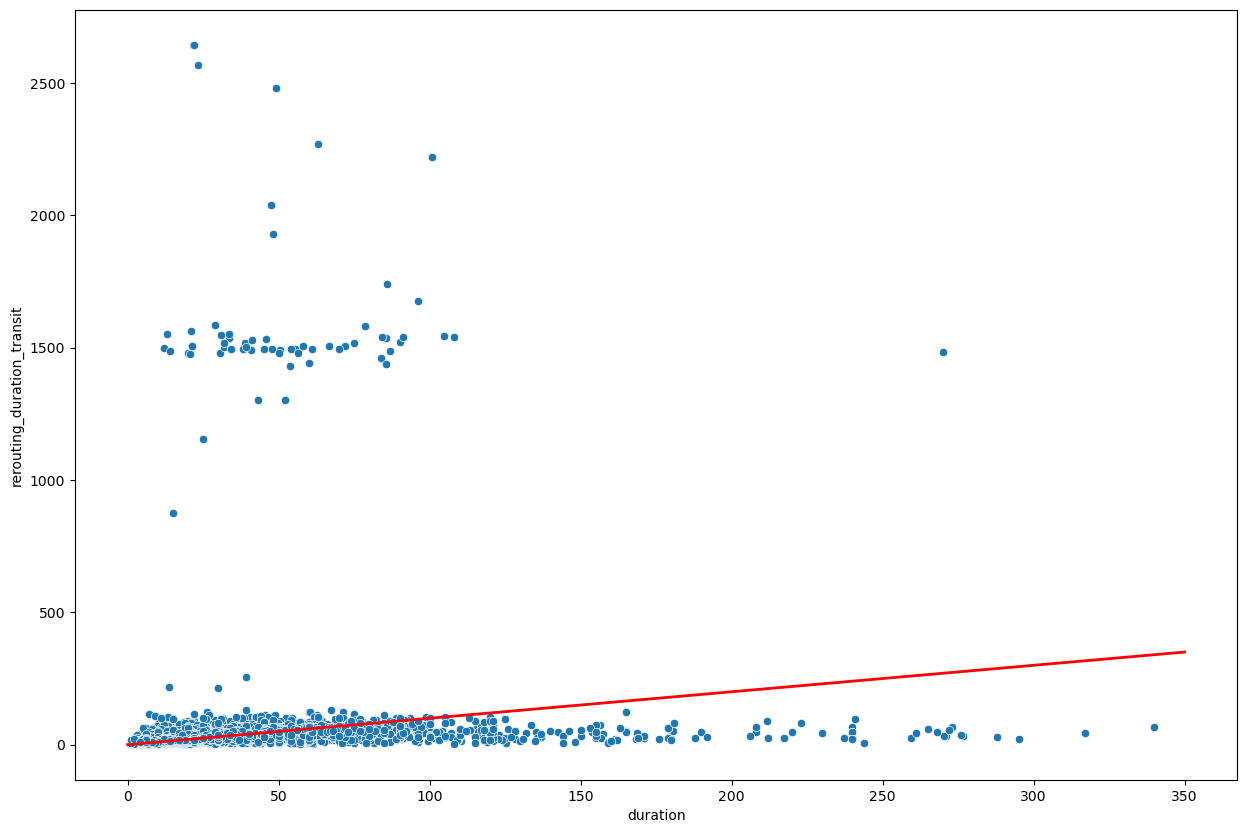

In [65]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.scatterplot(data=df[(df["mode"] == "Transit") & (df["rerouting_duration_transit"] >= 0)], x="duration", y="rerouting_duration_transit", ax=ax)
x_ref = np.linspace(0, 350)
plt.plot(x_ref, x_ref, color="r", linewidth=2)

(0.0, 200.0)

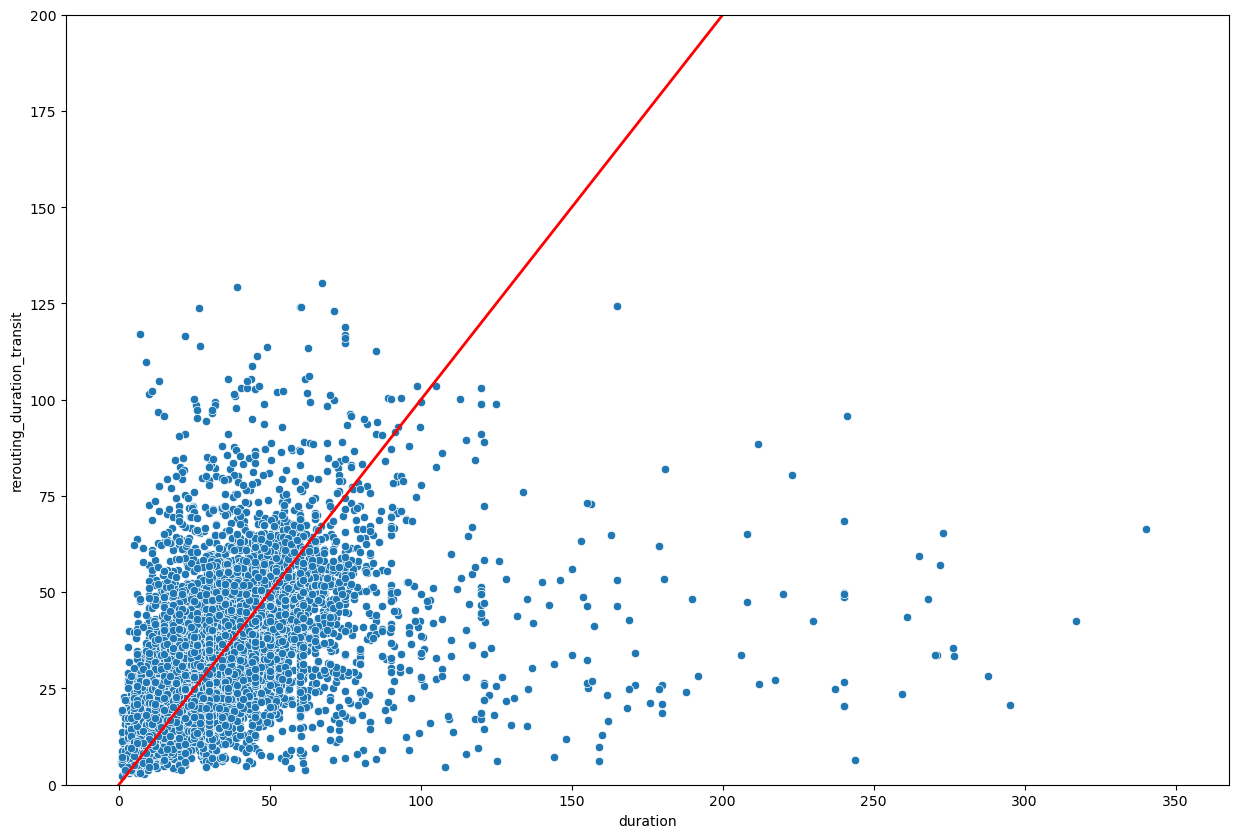

In [66]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.scatterplot(data=df[(df["mode"] == "Transit") & (df["rerouting_duration_transit"] >= 0)], x="duration", y="rerouting_duration_transit", ax=ax)
x_ref = np.linspace(0, 350)
plt.plot(x_ref, x_ref, color="r", linewidth=2)
ax.set_ylim(0, 200)

As seen previuosly, the % of linked trips with rerouting duration greater/less than observed are roughly equal, but hte magnitudes for these are no insignificant, with 80% of trips having an aboslute difference of 18 minutes between the two.

In [67]:
(df[(df["mode"] == "Transit") & (df["rerouting_duration_transit"] >= 0)]["duration"] - df[(df["mode"] == "Transit") & (df["rerouting_duration_transit"] >= 0)]["rerouting_duration_transit"]).describe(percentiles=[0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95])

count    9256.000000
mean       -8.403078
std       130.285078
min     -2621.716667
5%        -26.920833
10%       -17.958333
15%       -13.262500
20%       -10.000000
25%        -7.683333
50%        -0.016667
60%         2.783333
70%         5.883333
75%         7.687500
80%        10.033333
85%        13.562500
90%        18.516667
95%        30.787500
max       274.400000
dtype: float64

Comparing the summary statistics of rerouted and observed distances for observed transit trips that had a corresponding rerouted transit trip found for them, it seems that the rerouting analysis tend sto overestimate the distance of a trip. This could be due to the fact that transit trips in the TBI generally didn't seem to include the access/egress parts. 

In [68]:
pd.concat([df[(df["mode"] == "Transit") & (df["rerouting_duration_transit"] >= 0)]["rerouting_distance_transit"].describe(), df[(df["mode"] == "Transit") & (df["rerouting_duration_transit"] >= 0)]["distance"].describe()], axis=1)

,rerouting_distance_transit,distance
count,9256.000000,9256.000000
mean,5.710352,5.161800
std,4.738853,4.628752
min,0.213897,0.056540
25%,2.291076,1.978273
50%,4.380340,3.839789
75%,7.642469,6.786008
max,44.201259,70.046313


This scatter plot represents the rerouted/observed distances for observed transit trips that had a corresopnding rerouted transit trip found for them. In general, it seems that these two distances mirror each other roughly, clustering around y=x, although there is a small outlier cluster with high observed distance despite a low rerouted distance. 

(0.0, 200.0)

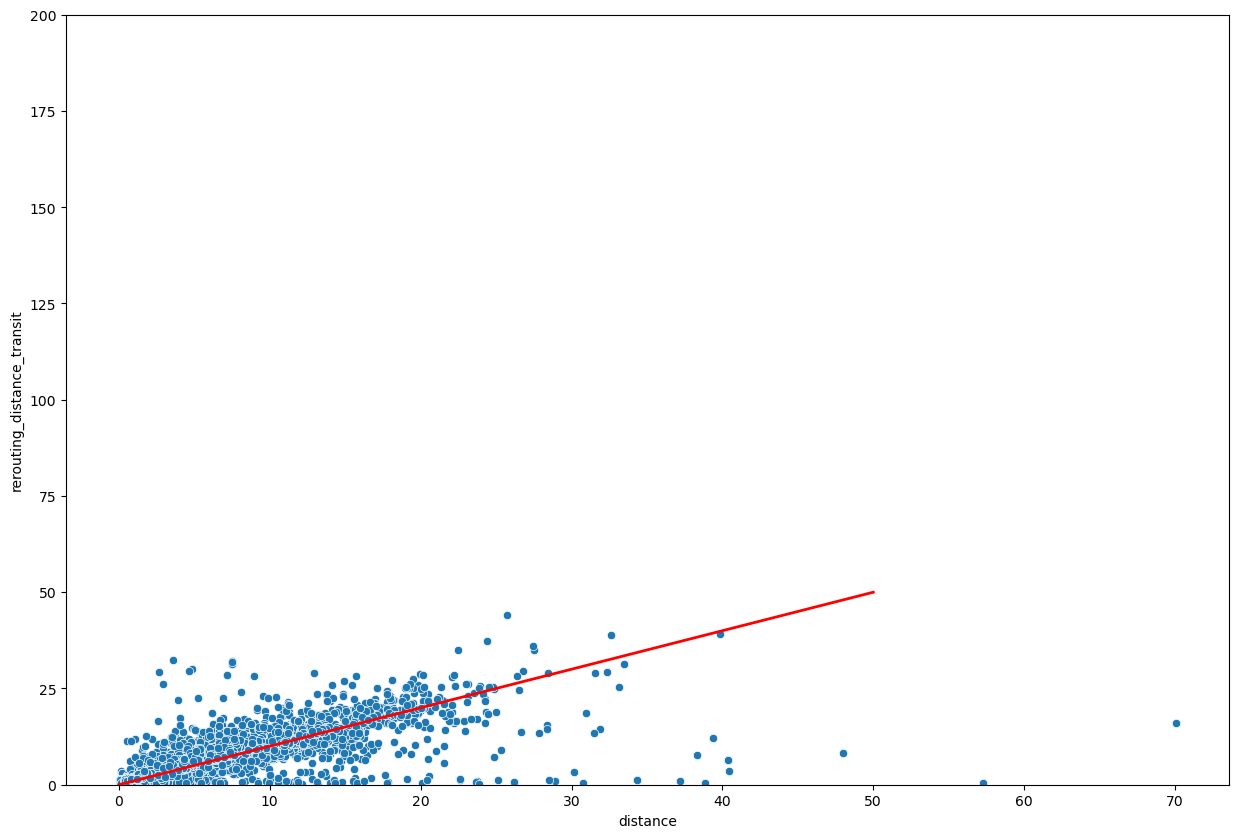

In [69]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.scatterplot(data=df[(df["mode"] == "Transit") & (df["rerouting_duration_transit"] >= 0)], x="distance", y="rerouting_distance_transit", ax=ax)
x_ref = np.linspace(0, 50)
plt.plot(x_ref, x_ref, color="r", linewidth=2)
ax.set_ylim(0, 200)

The summary statsitics for the differences between observed/rerouted distances are more varied than those for durations. About 75% of transit linked trips have a larger observed distance, while the other 25% have a larger rerouted disatnce. The overlal magnitudes of difference seem to be relatively low, with 80% (15-95) of trips having an absolute difference of about 1.7 miles. 

In [70]:
(df[(df["mode"] == "Transit") & (df["rerouting_duration_transit"] >= 0)]["distance"] - df[(df["mode"] == "Transit") & (df["rerouting_duration_transit"] >= 0)]["rerouting_distance_transit"]).describe(percentiles=[0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95])

count    9256.000000
mean       -0.548552
std         2.839456
min       -28.846493
5%         -3.889204
10%        -2.437379
15%        -1.733568
20%        -1.317859
25%        -1.080410
50%        -0.368536
60%        -0.195261
70%        -0.067634
75%        -0.011684
80%         0.091252
85%         0.276254
90%         0.640803
95%         1.694129
max        56.907444
dtype: float64

## Overall comparisons

### Comparison of summary statistics

The medians for durations from shortest to longest go like walk < car < bike < transit

In [71]:
summary = pd.concat([df[df["mode"] == "Car"]["duration"].describe(), df[df["mode"] == "Bike/Scooter"]["duration"].describe(), df[df["mode"] == "Walk"]["duration"].describe(), df[df["mode"] == "Transit"]["duration"].describe()], axis=1)
summary.columns = ["Car", "Bike", "Walk", "Transit"]
summary

,Car,Bike,Walk,Transit
count,380027.000000,7692.000000,49670.000000,11269.000000
mean,18.652677,23.616316,16.067523,35.239585
std,21.940639,25.960970,18.711005,28.008861
min,0.100000,0.600000,0.100000,0.200000
25%,8.100000,9.000000,6.200000,18.000000
50%,13.800000,16.000000,11.300000,30.000000
75%,22.100000,29.000000,19.200000,45.000000
max,971.000000,325.800000,325.000000,570.000000


When looking at the relative order of the rerouted durations, the same order is observed, although while car and walk duration decrease with rerouting, transit and bike increase slightly.

In [72]:
summary = pd.concat([df[df["mode"] == "Car"]["rerouting_duration_car"].describe(), df[df["mode"] == "Bike/Scooter"]["rerouting_duration_bike"].describe(), df[df["mode"] == "Walk"]["rerouting_duration_walk"].describe(), df[(df["mode"] == "Transit") & (df["rerouting_duration_transit"] >= 0)]["rerouting_duration_transit"].describe()], axis=1)
summary.columns = ["Car", "Bike", "Walk", "Transit"]
summary

,Car,Bike,Walk,Transit
count,380026.000000,7692.000000,49670.000000,9256.000000
mean,12.609590,31.883323,11.819962,41.745333
std,10.633773,30.071452,19.398401,130.905031
min,0.000000,0.000000,0.000000,2.183333
25%,5.373333,13.680833,4.421667,18.883333
50%,9.593333,24.905000,7.608333,28.366667
75%,16.588333,41.244583,13.251667,40.533333
max,139.815000,640.430000,997.553333,2643.716667


The medians for observed distances from shortest to longest go walk, bike, car, and then transit. 

In [73]:
summary = pd.concat([df[df["mode"] == "Car"]["distance"].describe(), df[df["mode"] == "Bike/Scooter"]["distance"].describe(), df[df["mode"] == "Walk"]["distance"].describe(), df[df["mode"] == "Transit"]["distance"].describe()], axis=1)
summary.columns = ["Car", "Bike", "Walk", "Transit"]
summary

,Car,Bike,Walk,Transit
count,380027.000000,7692.000000,49670.000000,11269.000000
mean,7.029822,3.239614,0.703522,6.974695
std,8.605750,4.222073,1.243842,7.471775
min,0.010271,0.057926,0.010238,0.056540
25%,1.650660,0.834450,0.217010,2.156030
50%,3.931170,1.857828,0.400441,4.422960
75%,9.216220,4.057700,0.764565,8.848897
max,99.978130,80.358668,55.865006,70.046313


The relative orders of distances for these modes when considering rerouting is the same, with car and bike median distance increasingly marginally and walk/transit decreasing marginally. 

In [85]:
summary = pd.concat([df[df["mode"] == "Car"]["rerouting_distance_car"].describe(), df[df["mode"] == "Bike/Scooter"]["rerouting_distance_bike"].describe(), df[df["mode"] == "Walk"]["rerouting_distance_walk"].describe(), df[(df["mode"] == "Transit") & (df["rerouting_duration_transit"] >= 0)]["rerouting_distance_transit"].describe()], axis=1)
summary.columns = ["Car", "Bike", "Walk", "Transit"]
summary

,Car,Bike,Walk,Transit
count,380026.000000,7692.000000,49670.000000,9256.000000
mean,7.282469,3.744724,0.610839,5.710352
std,8.608094,4.297965,1.001299,4.738853
min,0.000000,0.000000,0.000000,0.213897
25%,1.761214,1.122584,0.228665,2.291076
50%,4.201524,2.378422,0.393390,4.380340
75%,9.657395,4.779244,0.685124,7.642469
max,119.531834,81.547114,51.582244,44.201259


When looking at the average speeds by modes (accounting for differences in distances w.r.t. duration), things make sense, with walk being the slowest, followed by biking, transit, and then car.

In [108]:
summary = pd.concat([(df[df["mode"] == "Car"]["rerouting_distance_car"] / (df[df["mode"] == "Car"]["rerouting_duration_car"] + 1) * 60).describe(), (df[df["mode"] == "Bike/Scooter"]["rerouting_distance_bike"] / (df[df["mode"] == "Bike/Scooter"]["rerouting_duration_bike"] + 1) * 60).describe(), (df[df["mode"] == "Walk"]["rerouting_distance_walk"] / (df[df["mode"] == "Walk"]["rerouting_duration_walk"] + 1) * 60).describe(), (df[(df["mode"] == "Transit") & (df["rerouting_duration_transit"] >= 0)]["rerouting_distance_transit"] / (df[(df["mode"] == "Transit") & (df["rerouting_duration_transit"] >= 0)]["rerouting_duration_transit"] + 1) * 60).describe()], axis=1)
summary.columns = ["Car", "Bike", "Walk", "Transit"]
summary

,Car,Bike,Walk,Transit
count,380026.000000,7692.000000,49670.000000,9256.000000
mean,25.211046,6.775092,2.659164,9.431820
std,11.214768,3.792482,0.343001,4.101517
min,0.000000,0.000000,0.000000,0.009380
25%,16.090692,3.924312,2.528446,6.625397
50%,23.777103,6.191612,2.743065,9.021593
75%,33.955535,8.962470,2.885804,11.539046
max,62.732291,26.404920,3.100017,42.982266


### Intra-mode validation


When grouping by observed mode and looking at the rerouted durations for each one, the relative orderings of durations are still maintained. The only deviation from this is with hte observed walking trips, where biking is slightly slower than walking. 

This is only true with weights being used as the measure for duration; with the actual duration, biking remains the slowest among all of these groupings.

In [132]:
pd.concat([df[df["mode"] == "Walk"]["rerouting_duration_walk"].describe(), df[df["mode"] == "Walk"]["rerouting_duration_bike"].describe(), df[df["mode"] == "Walk"]["rerouting_duration_car"].describe(), df[df["mode"] == "Walk"]["rerouting_duration_transit"].describe()], axis=1)

,rerouting_duration_walk,rerouting_duration_bike,rerouting_duration_car,rerouting_duration_transit
count,49670.000000,49670.000000,49670.000000,49670.000000
mean,11.819962,12.201289,2.659100,10.439159
std,19.398401,15.540315,2.448100,37.876360
min,0.000000,0.000000,0.000000,-1.000000
25%,4.421667,3.473333,1.191667,-1.000000
50%,7.608333,8.191667,2.011667,9.566667
75%,13.251667,15.875000,3.363333,15.200000
max,997.553333,646.328333,72.991667,2668.366667


In [137]:
pd.concat([df[df["mode"] == "Bike/Scooter"]["rerouting_duration_walk"].describe(), df[df["mode"] == "Bike/Scooter"]["rerouting_duration_bike"].describe(), df[df["mode"] == "Bike/Scooter"]["rerouting_duration_car"].describe(), df[df["mode"] == "Bike/Scooter"]["rerouting_duration_transit"].describe()], axis=1)

,rerouting_duration_walk,rerouting_duration_bike,rerouting_duration_car,rerouting_duration_transit
count,7692.000000,7692.000000,7692.000000,7692.000000
mean,50.121659,31.883323,7.634847,27.114606
std,56.153808,30.071452,5.496350,118.121042
min,0.000000,0.000000,0.000000,-1.000000
25%,15.547917,13.680833,3.468333,4.020833
50%,32.110000,24.905000,6.313333,17.383333
75%,65.127500,41.244583,10.532917,29.066667
max,1059.886667,640.430000,55.828333,2701.066667


In [134]:
pd.concat([df[df["mode"] == "Car"]["rerouting_duration_walk"].describe(), df[df["mode"] == "Car"]["rerouting_duration_bike"].describe(), df[df["mode"] == "Car"]["rerouting_duration_car"].describe(), df[df["mode"] == "Car"]["rerouting_duration_transit"].describe()], axis=1)

,rerouting_duration_walk,rerouting_duration_bike,rerouting_duration_car,rerouting_duration_transit
count,380027.000000,380027.000000,380026.000000,380027.000000
mean,131.000727,85.566858,12.609590,30.176223
std,162.337105,90.985049,10.633773,169.015263
min,0.000000,0.000000,0.000000,-1.000000
25%,31.364167,31.555000,5.373333,-1.000000
50%,73.085000,57.016667,9.593333,-1.000000
75%,168.165000,104.678333,16.588333,22.350000
max,2193.931667,1244.070000,139.815000,2856.300000


In [135]:
pd.concat([df[df["mode"] == "Transit"]["rerouting_duration_walk"].describe(), df[df["mode"] == "Transit"]["rerouting_duration_bike"].describe(), df[df["mode"] == "Transit"]["rerouting_duration_car"].describe(), df[df["mode"] == "Transit"]["rerouting_duration_transit"].describe()], axis=1)

,rerouting_duration_walk,rerouting_duration_bike,rerouting_duration_car,rerouting_duration_transit
count,11269.000000,11269.000000,11269.000000,11269.000000
mean,118.186097,65.715081,13.660002,34.109664
std,129.173119,63.611944,9.447257,119.761891
min,0.000000,0.000000,0.000000,-1.000000
25%,37.751667,28.911667,7.208333,11.900000
50%,75.263333,48.060000,11.465000,24.033333
75%,148.445000,82.008333,17.390000,37.400000
max,1352.300000,697.958333,87.771667,2643.716667


### Clustering analysis

Scatter plots to visualize clusters of observed vs rerouting by mode:

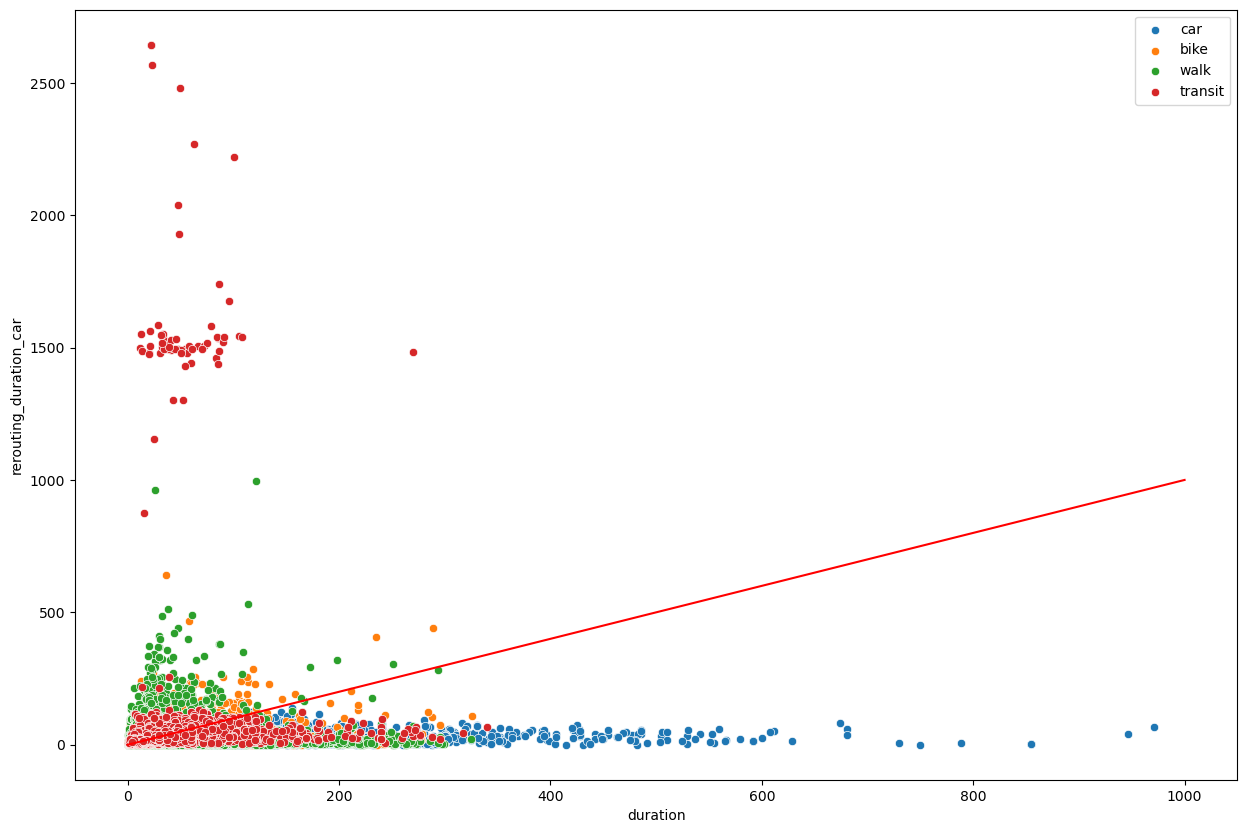

In [75]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.scatterplot(data=df[df["mode"] == "Car"], x="duration", y="rerouting_duration_car", ax=ax, label="car")
sns.scatterplot(data=df[df["mode"] == "Bike/Scooter"], x="duration", y="rerouting_duration_bike", ax=ax, label="bike")
sns.scatterplot(data=df[df["mode"] == "Walk"], x="duration", y="rerouting_duration_walk", ax=ax, label="walk")
sns.scatterplot(data=df[(df["mode"] == "Transit") & (df["rerouting_duration_transit"] >= 0)], x="duration", y="rerouting_duration_transit", ax=ax, label="transit")
x = np.linspace(0, 1000)
plt.plot(x, x, color="r")
plt.legend()

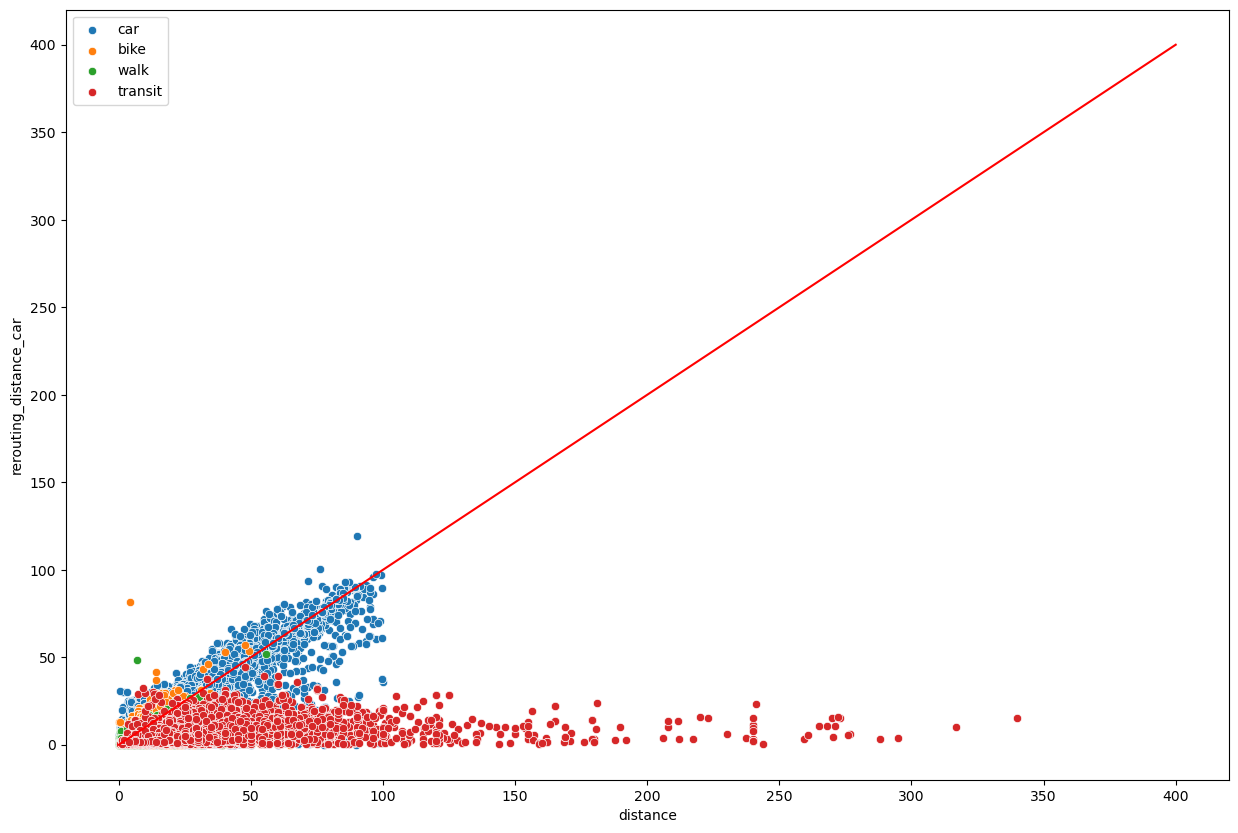

In [157]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.scatterplot(data=df[df["mode"] == "Car"], x="distance", y="rerouting_distance_car", ax=ax, label="car")
sns.scatterplot(data=df[df["mode"] == "Bike/Scooter"], x="distance", y="rerouting_distance_bike", ax=ax, label="bike")
sns.scatterplot(data=df[df["mode"] == "Walk"], x="distance", y="rerouting_distance_walk", ax=ax, label="walk")
sns.scatterplot(data=df[(df["mode"] == "Transit") & (df["rerouting_duration_transit"] >= 0)], x="duration", y="rerouting_distance_transit", ax=ax, label="transit")
x = np.linspace(0, 400)
plt.plot(x, x, color="r")
plt.legend()